# Testing Lawgic Using LangChain and Groq
(because RAG in Vertex AI is paid...)

In [21]:
# %pip install langchain langchain-community pypdf
# %pip install langsmith
# %pip install langchain-groq
# %pip install langchain langchain-text-splitters langchain-community bs4
# %pip install langchain-chroma
# %pip install sentence-transformers
# %pip install ipywidgets
# %pip install langchain-huggingface
# %pip install ragas rapidfuzz
%pip install rank_bm25

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import getpass
from dotenv import load_dotenv

import json
import copy
import pandas as pd
import numpy as np
import re
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Optional

# Setup

1. Chat Model

In [3]:
from langchain_groq import ChatGroq

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

qwen = "qwen/qwen3-32b"
llama = "llama-3.3-70b-versatile"

llm = ChatGroq(
    model=qwen,  # or another Groq model
    temperature=0,
)

2. Embeddings Model

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

3. Vector Store

In [5]:
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="example_rag_langchain_collection",
    embedding_function=embeddings,
    persist_directory="../collections/chroma_langchain_db",  # Where to save data locally, remove if not necessary
)

## View CUAD json dataset 

CUAD Dataset Structure in SQuAD (Stanford Question Answering Dataset) Format

CUAD_v1.json
- version: "aok_v1.0"
- data: [510 contracts]
    - each contract:
        - title: "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"
        - paragraphs: [1 paragraph per contract]
            - each paragraph:
                - context: (the FULL contract text, 54,290 chars for this one)
                - qas: [41 question-answer pairs]
                    - each qa:
                        - id: "LIMEENERGYCO_...__Exclusivity"
                        - question: "Highlight the parts (if any)..."
                        - is_impossible: true/false
                        - answers: [{text, answer_start}, ...]

In [6]:
CUAD_PATH = "../datasets/CUAD_v1/CUAD_v1.json"
SAMPLE_CONTRACT_TITLE = "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"

# 1. Load Data (Your existing code)
print("Loading CUAD dataset...")
with open(CUAD_PATH, 'r', encoding='utf-8') as f:
    cuad_data = json.load(f)
print(f"✓ CUAD dataset loaded successfully")

# 2. Find the specific contract by Title
# We use 'next' to find the first match in the list
target_contract = next((c for c in cuad_data['data'] if c['title'] == SAMPLE_CONTRACT_TITLE), None)

if target_contract:
    # 3. Create a clean "Preview" copy
    # We use deepcopy so we don't accidentally delete data from the real dataset variables
    preview = copy.deepcopy(target_contract)

    # 4. Truncate the massive fields for display purposes
    for p in preview['paragraphs']:
        # Truncate the 54k character context to just the start and end
        full_text_len = len(p['context'])
        p['context'] = f"{p['context'][:300]} ... [TRUNCATED {full_text_len} CHARS] ... {p['context'][-300:]}"
        
        # Optional: Truncate QAs if you just want to see the structure
        # (Comment this out if you want to see ALL 41 questions)
        total_qas = len(p['qas'])
        if total_qas > 3:
            p['qas'] = p['qas'][:3] + [{f"... {total_qas - 3} more QAs hidden ...": "..."}]

    # 5. Print with indentation
    print(f"\n--- Structure for: {SAMPLE_CONTRACT_TITLE} ---\n")
    print(json.dumps(preview, indent=2))

else:
    print(f"Could not find contract: {SAMPLE_CONTRACT_TITLE}")

Loading CUAD dataset...
✓ CUAD dataset loaded successfully

--- Structure for: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT ---

{
  "title": "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT",
  "paragraphs": [
    {
      "qas": [
        {
          "answers": [
            {
              "text": "DISTRIBUTOR AGREEMENT",
              "answer_start": 44
            }
          ],
          "id": "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name",
          "question": "Highlight the parts (if any) of this contract related to \"Document Name\" that should be reviewed by a lawyer. Details: The name of the contract",
          "is_impossible": false
        },
        {
          "answers": [
            {
              "text": "Distributor",
              "answer_start": 244
            },
            {
              "text": "Electric City Corp.",
              "answer_start": 148
            },
            {
              "text": "Electric City of Illinoi

## Testing RAG Using LangChain

Skip to the following section and start execution there if testing isn't necessary:
- [Benchmarking Helper Function Setup](#benchmark-helper-functions)

### Quick Test Runs

#### Semantic Search

In [11]:
from langchain_community.document_loaders import PyPDFLoader

sample_file_path = "../datasets/CUAD_v1/full_contract_pdf/Part_III/Distributor/LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT.PDF"
loader = PyPDFLoader(sample_file_path)

docs = loader.load()

print(len(docs))


10


In [12]:
print(f"{docs[0].page_content[:200]}\n")
print(docs[0].metadata)

EXHIBIT 10.6
                              DISTRIBUTOR AGREEMENT
         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between
Electric City Corp.,  a Delaware  corporation  ("Compa

{'producer': 'EVO HTML to PDF Converter 7.4', 'creator': 'PyPDF', 'creationdate': '', 'source': '../datasets/CUAD_v1/full_contract_pdf/Part_III/Distributor/LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT.PDF', 'total_pages': 10, 'page': 0, 'page_label': '1'}


In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)
all_splits = text_splitter.split_documents(docs)

print(len(all_splits))

71


In [14]:
vector_1 = embeddings.embed_query(all_splits[0].page_content)
vector_2 = embeddings.embed_query(all_splits[1].page_content)

assert len(vector_1) == len(vector_2)
print(f"Generated vectors of length {len(vector_1)}\n")
print(vector_1[:10])

Generated vectors of length 768

[0.021088002249598503, -0.0011535205412656069, 0.02359265275299549, -0.004085799679160118, -0.016694307327270508, 0.011954566463828087, 0.0715947300195694, -0.005269474349915981, 0.015024959109723568, -0.02905212715268135]


In [15]:
ids = vector_store.add_documents(documents=all_splits)

In [16]:
results = vector_store.similarity_search_with_score(
    "What happens if either the Distributor or the Company fails to comply with the terms of the agreement?"
)

for result in results:
    doc, score = result
    print(f"Score: {score}")
    print(doc)
    print("--------------------------------------------------------------------------------------------------------------------------------")
    print("\n")

Score: 0.6187871694564819
page_content='4.       DURATION AND TERMINATION
         4.1      Duration.   Unless  earlier   terminated   otherwise  provided
                  therein,  this  Agreement,  subject to the  commencement  date
                  established  in Section 1.3,  shall be effective  immediately.
                  Distributor  shall submit written  reports to the Company each
                  quarter during the first year of the Term,  commencing  ninety
                  (90) days after  execution of this  Agreement,  describing its
                  efforts,  the potential  customers it has  approached  and the
                  status of its efforts.
         4.2      Termination  for  Cause.   Either  party  may  terminate  this
                  Agreement upon 30 days
                                    Page -8-
                  prior written  notice to the other upon the  occurrence of any
                  of the following events: (A) the Distributor's failu

#### RAG Agent
One formulation of a RAG application is as a simple agent with a tool that retrieves information. We can assemble a minimal RAG agent by implementing a tool that wraps our vector store:

In [35]:
from langchain.tools import tool

@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve information to help answer a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

In [21]:
from langchain.agents import create_agent

tools = [retrieve_context]
# If desired, specify custom instructions
prompt = (
    "You have access to a tool that retrieves context from a legal document. "
    "Use the tool to help answer user queries."
)
agent = create_agent(llm, tools, system_prompt=prompt)

In [22]:
query = (
    "What happens if either the Distributor or the Company fails to comply with the terms of the agreement?\n\n"
    "Once you get the answer, search for the relevant clauses in the document and provide them."
)

for event in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


================================ Human Message =================================

What happens if either the Distributor or the Company fails to comply with the terms of the agreement?

Once you get the answer, search for the relevant clauses in the document and provide them.
================================== Ai Message ==================================
Tool Calls:
  retrieve_context (7850sjedz)
 Call ID: 7850sjedz
  Args:
    query: consequences of non-compliance with agreement terms by Distributor or Company
================================= Tool Message =================================
Name: retrieve_context

Source: {'source': '../datasets/CUAD_v1/full_contract_pdf/Part_III/Distributor/LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT.PDF', 'producer': 'EVO HTML to PDF Converter 7.4', 'page_label': '7', 'page': 6, 'creationdate': '', 'total_pages': 10, 'creator': 'PyPDF', 'start_index': 4742}
Content: (C)      Company  will  timely  furnish  all of  Distributor's
             

Another common approach is a two-step chain, in which we always run a search (potentially using the raw user query) and incorporate the result as context for a single LLM query. This results in a single inference call per query, buying reduced latency at the expense of flexibility.

In this approach we no longer call the model in a loop, but instead make a single pass.

In [23]:
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@dynamic_prompt
def prompt_with_context(request: ModelRequest) -> str:
    """Inject context into state messages."""
    last_query = request.state["messages"][-1].text
    retrieved_docs = vector_store.similarity_search(last_query)

    docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

    system_message = (
        "You are a helpful assistant. Use the following context in your response:"
        f"\n\n{docs_content}"
    )

    return system_message   

agent = create_agent(llm, tools=[], middleware=[prompt_with_context])

In [24]:
query = "What happens if either the Distributor or the Company fails to comply with the terms of the agreement?"
for step in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What happens if either the Distributor or the Company fails to comply with the terms of the agreement?
================================== Ai Message ==================================

According to the agreement, if either the Distributor or the Company fails to comply with the terms of the agreement, the other party may terminate the agreement upon 30 days' prior written notice. This is stated in Section 4.2, "Termination for Cause".

Specifically, the agreement states that either party may terminate the agreement if the other party fails to make payments, or if there are other events that trigger termination, such as the Distributor's failure to meet its obligations.

Additionally, if the Company terminates the agreement without cause and for reasons other than the Distributor's failure to meet its minimum expectations, the Company shall repurchase from the Distributor any products in the Distributor's 

#### Benchmark Helper Functions

##### Text Matching

In [ ]:
def _normalize(text: str) -> str:
    """Collapse whitespace and lowercase for text comparison."""
    return re.sub(r'\s+', ' ', text.lower().strip())


def _text_in(needle: str, haystack: str, min_words: int = 6) -> bool:
    """Check if needle text appears in haystack (handles whitespace differences).

    For longer texts, also checks if a contiguous segment of min_words
    consecutive words from the needle appears in the haystack. This handles
    cases where the answer spans chunk boundaries.
    """
    n, h = _normalize(needle), _normalize(haystack)
    if n in h:
        return True
    words = n.split()
    if len(words) >= min_words:
        for i in range(len(words) - min_words + 1):
            if ' '.join(words[i:i + min_words]) in h:
                return True
    return False


def _text_in_any(text: str, answer_texts: List[str]) -> bool:
    """Check if text contains any of the answer texts."""
    return any(_text_in(ans, text) for ans in answer_texts)

print("Defined text matching helper functions.")


##### Building ground truth dataset

In [12]:
def build_eval_dataset(
    cuad_path: str,
    contract_title: str,
    chunks: list,
    custom_samples: Optional[List[Dict]] = None,
) -> List[Dict]:
    """Build retrieval evaluation dataset from CUAD annotations + custom queries.

    Maps CUAD ground-truth answer spans to your actual document chunks,
    creating a benchmark dataset for measuring retrieval quality.

    Args:
        cuad_path: Path to CUAD_v1.json
        contract_title: Exact title of the contract in CUAD
        chunks: Document chunks from text_splitter.split_documents()
        custom_samples: Extra test cases. Each dict needs:
            - 'query': str (the question to ask)
            - 'answer_text': str (expected text that should be in retrieved chunks)
            - 'category': str (optional label, defaults to 'custom')

    Returns:
        List of eval samples for use with evaluate_retrieval()
    """
    with open(cuad_path) as f:
        cuad = json.load(f)

    contract = next((d for d in cuad['data'] if d['title'] == contract_title), None)
    if not contract:
        raise ValueError(f"Contract '{contract_title}' not found in CUAD")

    dataset = []

    # --- CUAD QA pairs ---
    for qa in contract['paragraphs'][0]['qas']:
        if qa.get('is_impossible') or not qa.get('answers'):
            continue

        answer_texts = list({a['text'] for a in qa['answers']})
        category = qa['id'].rsplit('__', 1)[-1] if '__' in qa['id'] else 'unknown'

        relevant_idx = set()
        for ans in answer_texts:
            for i, chunk in enumerate(chunks):
                if _text_in(ans, chunk.page_content):
                    relevant_idx.add(i)

        if relevant_idx:
            dataset.append({
                'query': qa['question'],
                'answer_texts': answer_texts,
                'reference_contexts': [chunks[i].page_content for i in sorted(relevant_idx)],
                'reference_chunk_indices': sorted(relevant_idx),
                'category': category,
            })

    # --- Custom queries ---
    for cs in (custom_samples or []):
        idx = [i for i, c in enumerate(chunks) if _text_in(cs['answer_text'], c.page_content)]
        if idx:
            dataset.append({
                'query': cs['query'],
                'answer_texts': [cs['answer_text']],
                'reference_contexts': [chunks[i].page_content for i in idx],
                'reference_chunk_indices': idx,
                'category': cs.get('category', 'custom'),
            })
        else:
            print(f"Warning: No matching chunks found for custom query: {cs['query'][:60]}...")

    return dataset

print("Defined ground truth dataset builder.")

Defined ground truth dataset builder.


##### Retrieval Evaluation

In [13]:
def evaluate_retrieval(
    retriever,
    eval_dataset: List[Dict],
    k: int = 4,
    chunks: Optional[list] = None,
    llm=None,
    run_llm_metrics: bool = False,
    verbose: bool = True,
) -> Dict:
    """Evaluate RAG retrieval quality. Re-run after any pipeline change.

    Metrics:
        Fast (always, no API calls):
            hit_rate@K, mrr, precision@K, recall@K, ndcg@K
        RAGAS LLM (optional, set run_llm_metrics=True):
            context_recall, context_precision

    Args:
        retriever: vector_store (with .similarity_search) or fn(query, k) -> [Doc]
        eval_dataset: From build_eval_dataset()
        k: Number of chunks to retrieve per query
        chunks: Original document chunks (e.g. all_splits) for identifying
                chunk indices. When provided, inspect_query() will show which
                chunk numbers were retrieved vs. expected.
        llm: LangChain LLM for RAGAS metrics (e.g. your ChatGroq instance)
        run_llm_metrics: Run RAGAS LLM-based metrics (slower, uses API)
        verbose: Print progress and summary

    Returns:
        dict with 'summary', 'per_query', and 'dataframe' keys

    Usage:
        # Fast evaluation (instant, with chunk tracking):
        results = evaluate_retrieval(vector_store, eval_dataset, k=4, chunks=all_splits)

        # With RAGAS LLM metrics:
        results = evaluate_retrieval(vector_store, eval_dataset, k=4,
                                     chunks=all_splits, llm=llm, run_llm_metrics=True)
    """
    retrieve_fn = (
        (lambda q, num: retriever.similarity_search(q, k=num))
        if hasattr(retriever, 'similarity_search')
        else retriever
    )

    # Build a lookup from chunk content -> index for identifying retrieved chunks
    _chunk_index_map = {}
    if chunks is not None:
        for ci, ch in enumerate(chunks):
            _chunk_index_map[ch.page_content] = ci

    per_query = []
    if verbose:
        print(f"Evaluating {len(eval_dataset)} queries (k={k})...\n")

    for i, sample in enumerate(eval_dataset):
        docs = retrieve_fn(sample['query'], k)
        texts = [d.page_content if hasattr(d, 'page_content') else str(d) for d in docs]
        relevance = [_text_in_any(t, sample['answer_texts']) for t in texts]
        n_rel = len(sample['reference_contexts'])

        # Identify chunk index for each retrieved document
        chunk_indices = [_chunk_index_map.get(t) for t in texts] if _chunk_index_map else None

        # --- Standard IR Metrics ---
        hit = 1.0 if any(relevance) else 0.0
        mrr = next((1.0 / (j + 1) for j, r in enumerate(relevance) if r), 0.0)
        prec = sum(relevance) / len(relevance) if relevance else 0.0
        rec = sum(relevance) / n_rel if n_rel else 0.0
        dcg = sum((1 if r else 0) / np.log2(j + 2) for j, r in enumerate(relevance))
        ideal = sorted(relevance, reverse=True)
        idcg = sum((1 if r else 0) / np.log2(j + 2) for j, r in enumerate(ideal))
        ndcg = dcg / idcg if idcg else 0.0

        m = {
            'hit_rate': hit, 'mrr': mrr, 'precision_at_k': prec,
            'recall_at_k': rec, 'ndcg_at_k': ndcg,
            'query': sample['query'], 'category': sample['category'],
            'n_ref': n_rel, '_texts': texts, '_relevance': relevance,
            '_chunk_indices': chunk_indices,
        }
        per_query.append(m)

        if verbose:
            sym = "+" if hit else "X"
            print(f"  [{sym}] {i+1:2d}/{len(eval_dataset)} "
                  f"hit={hit:.0f} mrr={mrr:.2f} P@{k}={prec:.2f} R@{k}={rec:.2f} "
                  f"| {sample['category']}")

    # --- RAGAS LLM Metrics (optional) ---
    if run_llm_metrics:
        _run_ragas_metrics(eval_dataset, per_query, llm, verbose)

    # --- Summary ---
    fast_keys = ['hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']
    ragas_keys = sorted({key for r in per_query for key in r if key.startswith('ragas_')})
    all_keys = fast_keys + ragas_keys

    summary = {}
    for key in all_keys:
        vals = [r[key] for r in per_query if isinstance(r.get(key), (int, float))]
        if vals:
            summary[key] = {
                'mean': float(np.mean(vals)), 'std': float(np.std(vals)),
                'min': float(np.min(vals)), 'max': float(np.max(vals)),
            }

    df = pd.DataFrame([
        {col: r.get(col) for col in ['query', 'category', *all_keys, 'n_ref']}
        for r in per_query
    ])

    if verbose:
        print("\n" + "=" * 70)
        print(f"  RETRIEVAL BENCHMARK  |  k={k}  |  queries={len(eval_dataset)}")
        print("=" * 70)
        for key, s in summary.items():
            bar_len = int(s['mean'] * 20)
            bar = "#" * bar_len + "." * (20 - bar_len)
            print(f"  {key:30s} [{bar}] {s['mean']:.4f} (+/-{s['std']:.4f})")
        print("=" * 70)

    return {'summary': summary, 'per_query': per_query, 'dataframe': df}


def _run_ragas_metrics(eval_dataset, per_query, llm, verbose):
    """Run RAGAS LLM-based context recall & precision."""
    if llm is None:
        print("\nWarning: run_llm_metrics=True but no llm provided. Skipping RAGAS.")
        return
    try:
        from ragas import EvaluationDataset, evaluate as ragas_evaluate
        from ragas.llms import LangchainLLMWrapper
        from ragas.metrics import LLMContextRecall, LLMContextPrecisionWithReference

        if verbose:
            print("\nRunning RAGAS LLM metrics (this uses your LLM API)...")

        evaluator_llm = LangchainLLMWrapper(llm)
        ragas_samples = [{
            'user_input': s['query'],
            'retrieved_contexts': r['_texts'],
            'reference': ' '.join(s['answer_texts'][:3]),
        } for s, r in zip(eval_dataset, per_query)]

        result = ragas_evaluate(
            dataset=EvaluationDataset.from_list(ragas_samples),
            metrics=[LLMContextRecall(), LLMContextPrecisionWithReference()],
            llm=evaluator_llm,
        )
        rdf = result.to_pandas()
        ragas_cols = [c for c in rdf.columns
                      if c not in ('user_input', 'retrieved_contexts', 'reference')]
        for i in range(len(per_query)):
            for col in ragas_cols:
                val = rdf.iloc[i][col]
                per_query[i][f'ragas_{col}'] = float(val) if pd.notna(val) else None

        if verbose:
            print("  RAGAS metrics computed successfully.")
    except ImportError as e:
        print(f"\nWarning: RAGAS not available: {e}\n  Install: pip install ragas")
    except Exception as e:
        print(f"\nWarning: RAGAS evaluation failed: {e}")
        import traceback; traceback.print_exc()

print("Defined retrieval evaluation functions.")

Defined retrieval evaluation functions.


##### Diagnostics & Visualization 

In [14]:
def show_failures(results: Dict, eval_dataset: List[Dict]):
    """Show queries where retrieval failed to find any relevant chunk."""
    fails = [(r, s) for r, s in zip(results['per_query'], eval_dataset)
             if r['hit_rate'] == 0]
    if not fails:
        print("All queries found at least one relevant chunk!")
        return
    print(f"\n{len(fails)}/{len(eval_dataset)} queries FAILED retrieval:\n")
    for r, s in fails:
        print(f"  Category: {s['category']}")
        print(f"  Query:    {s['query'][:90]}")
        print(f"  Expected: chunks {s['reference_chunk_indices']}")
        print()


def inspect_query(results: Dict, eval_dataset: List[Dict], query_idx: int):
    """Deep-dive into a single query's retrieval results."""
    r = results['per_query'][query_idx]
    s = eval_dataset[query_idx]
    chunk_ids = r.get('_chunk_indices')

    expected = set(s['reference_chunk_indices'])
    retrieved = set(chunk_ids) - {None} if chunk_ids else set()

    print(f"{'='*70}")
    print(f"Query [{query_idx}]: {s['query'][:90]}")
    print(f"Category: {s['category']}")
    print(f"Hit: {'YES' if r['hit_rate'] else 'NO'}  |  MRR: {r['mrr']:.2f}  |  "
          f"P@K: {r['precision_at_k']:.2f}  |  R@K: {r['recall_at_k']:.2f}")

    if chunk_ids is not None:
        retrieved_ids = [c for c in chunk_ids if c is not None]
        found = expected & retrieved
        missed = expected - retrieved
        extra = retrieved - expected
        print(f"\n--- Chunk Comparison ---")
        print(f"  Expected chunks:  {sorted(expected)}")
        print(f"  Retrieved chunks: {retrieved_ids}")
        print(f"  Found (correct):  {sorted(found) if found else '(none)'}")
        print(f"  Missed:           {sorted(missed) if missed else '(none)'}")
        print(f"  Extra (noise):    {sorted(extra) if extra else '(none)'}")

    print(f"\n--- Expected Chunks (n={len(s['reference_chunk_indices'])}) ---")
    for ci, idx in enumerate(s['reference_chunk_indices']):
        print(f"  Chunk {idx}: {s['reference_contexts'][ci][:120]}...")

    print(f"\n--- Retrieved Chunks ---")
    for i, (text, rel) in enumerate(zip(r['_texts'], r['_relevance'])):
        tag = ">> RELEVANT" if rel else "   miss"
        cid = f"Chunk {chunk_ids[i]}" if chunk_ids and chunk_ids[i] is not None else "Chunk ?"
        print(f"  [{i+1}] {cid} {tag}: {text[:120]}...")
    print(f"{'='*70}")


def plot_results(results: Dict):
    """Visualize benchmark results with charts."""
    df = results['dataframe']
    summary = results['summary']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Aggregate metrics bar chart
    names = list(summary.keys())
    means = [summary[n]['mean'] for n in names]
    stds = [summary[n]['std'] for n in names]
    colors = sns.color_palette("viridis", len(names))
    bars = axes[0].bar(range(len(names)), means, yerr=stds, color=colors, capsize=4)
    axes[0].set_xticks(range(len(names)))
    axes[0].set_xticklabels([n.replace('_at_k', '@K').replace('_', '\n')
                              for n in names], fontsize=8)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_title('Aggregate Retrieval Metrics', fontweight='bold')
    for b, m in zip(bars, means):
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                    f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

    # 2. Hit rate by category
    cat_hr = df.groupby('category')['hit_rate'].mean().sort_values()
    c = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.8 else '#27ae60' for v in cat_hr]
    cat_hr.plot(kind='barh', ax=axes[1], color=c)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_title('Hit Rate by Clause Category', fontweight='bold')
    axes[1].set_xlabel('Hit Rate')

    # 3. MRR distribution
    axes[2].hist(df['mrr'], bins=np.arange(0, 1.2, 0.1),
                  color='steelblue', edgecolor='white')
    axes[2].axvline(df['mrr'].mean(), color='red', ls='--',
                     label=f"Mean: {df['mrr'].mean():.2f}")
    axes[2].set_title('MRR Distribution', fontweight='bold')
    axes[2].set_xlabel('MRR Score')
    axes[2].set_ylabel('Count')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


print("Defined visualizaton functions.")

Defined visualizaton functions.


After setting up helper functions, choose either:
- [RAG on one contract](#benchmark-rag-on-one-contract)
- [RAG on entire dataset](#benchmark-rag-on-entire-cuad-dataset)

### Benchmark RAG on ONE contract

To evaluate retrieval quality, we build a ground-truth dataset from CUAD annotations and measure how well our vector store retrieves the correct chunks.

**Fast Metrics** (no API calls, for rapid iteration):
- **Hit Rate@K**: Did we find at least one relevant chunk in the top-K?
- **MRR**: Mean Reciprocal Rank — how high is the first relevant result?
- **Precision@K**: What fraction of retrieved chunks are actually relevant?
- **Recall@K**: What fraction of all relevant chunks did we retrieve?
- **NDCG@K**: Normalized Discounted Cumulative Gain — ranking quality

**RAGAS LLM Metrics** (optional, deeper semantic analysis):
- **Context Recall**: Does the retrieved context cover all claims in the reference?
- **Context Precision**: Are relevant chunks ranked higher than irrelevant ones?

#### Execute RAG

In [15]:
from langchain_community.document_loaders import PyPDFLoader

sample_file_path = "../datasets/CUAD_v1/full_contract_pdf/Part_III/Distributor/LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT.PDF"
loader = PyPDFLoader(sample_file_path)

docs = loader.load()

print(len(docs))


10


In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)
all_splits = text_splitter.split_documents(docs)

print(len(all_splits))

71


In [17]:
# Build ground-truth evaluation dataset
CUAD_PATH = "../datasets/CUAD_v1/CUAD_v1.json"
CONTRACT_TITLE = "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"

# Add your own custom test queries here.
# Each needs a 'query' and the 'answer_text' you expect to find in the retrieved chunks.
custom_queries = [
    {
        "query": "What happens if either the Distributor or the Company fails to comply with the terms of the agreement?",
        "answer_text": (
            "Accrued Obligations. In the event that either Distributor or "
            "Company fails to comply with the terms of this Agreement, both "
            "Distributor and Company acknowledge and agree that in addition "
            "to any claim for damages either party may have arising from "
            "the default of the other, they shall have the right to seek "
            "equitable relief by way of a temporary restraining order, "
            "preliminary injunction, permanent injunction and such other "
            "equitable relief as may be appropriate."
        ),
        "category": "Equitable Relief",
    },
]

eval_dataset = build_eval_dataset(
    CUAD_PATH, CONTRACT_TITLE, all_splits, custom_samples=custom_queries
)

print(f"Evaluation dataset: {len(eval_dataset)} test queries")
print(f"Categories: {sorted(set(s['category'] for s in eval_dataset))}")
print(f"\nSample entry:")
print(f"  Query:    {eval_dataset[0]['query'][:80]}...")
print(f"  Category: {eval_dataset[0]['category']}")
print(f"  Answer Texts: {eval_dataset[0]['answer_texts']}")
print(f"  Reference Contexts: {eval_dataset[0]['reference_contexts']}")
print(f"  Relevant Chunks: {eval_dataset[0]['reference_chunk_indices']}")

Evaluation dataset: 20 test queries
Categories: ['Agreement Date', 'Anti-Assignment', 'Covenant Not To Sue', 'Document Name', 'Effective Date', 'Equitable Relief', 'Exclusivity', 'Expiration Date', 'Governing Law', 'Insurance', 'License Grant', 'Minimum Commitment', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Parties', 'Post-Termination Services', 'Price Restrictions', 'Renewal Term', 'Rofr/Rofo/Rofn', 'Warranty Duration']

Sample entry:
  Query:    Highlight the parts (if any) of this contract related to "Document Name" that sh...
  Category: Document Name
  Answer Texts: ['DISTRIBUTOR AGREEMENT']
  Reference Contexts: ['EXHIBIT 10.6\n                              DISTRIBUTOR AGREEMENT\n         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between\nElectric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of\nIllinois LLC ("Distributor") this 7th day of September, 1999.\n                                    RECITALS\n         A. The  Co

#### Evaluate Results

In [18]:
# ====================================================================
# RUN RETRIEVAL BENCHMARK
# Re-run this cell after any changes to your RAG pipeline
# (e.g. different embeddings, chunk size, overlap, k, etc.)
# ====================================================================

results = evaluate_retrieval(vector_store, eval_dataset, k=4, chunks=all_splits)

Evaluating 20 queries (k=4)...

  [X]  1/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Document Name
  [+]  2/20 hit=1 mrr=1.00 P@4=0.50 R@4=0.03 | Parties
  [X]  3/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Agreement Date
  [+]  4/20 hit=1 mrr=1.00 P@4=1.00 R@4=1.33 | Effective Date
  [+]  5/20 hit=1 mrr=1.00 P@4=0.50 R@4=2.00 | Expiration Date
  [+]  6/20 hit=1 mrr=1.00 P@4=0.50 R@4=0.67 | Renewal Term
  [X]  7/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Governing Law
  [X]  8/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Exclusivity
  [+]  9/20 hit=1 mrr=1.00 P@4=1.00 R@4=1.00 | No-Solicit Of Customers
  [+] 10/20 hit=1 mrr=1.00 P@4=0.50 R@4=0.33 | No-Solicit Of Employees
  [X] 11/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Rofr/Rofo/Rofn
  [+] 12/20 hit=1 mrr=1.00 P@4=0.50 R@4=0.50 | Anti-Assignment
  [+] 13/20 hit=1 mrr=1.00 P@4=1.00 R@4=1.33 | Price Restrictions
  [X] 14/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Minimum Commitment
  [X] 15/20 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | License Grant
  [X] 16/20 hit=0 mrr=0.0

Sanity check

In [19]:
inspect_query(results, eval_dataset, query_idx=1)

Query [1]: Highlight the parts (if any) of this contract related to "Parties" that should be reviewed
Category: Parties
Hit: YES  |  MRR: 1.00  |  P@K: 0.50  |  R@K: 0.03

--- Chunk Comparison ---
  Expected chunks:  [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 64, 65, 66, 67, 68, 69, 70]
  Retrieved chunks: [58, 58, 62, 62]
  Found (correct):  [58]
  Missed:           [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 64, 65, 66, 67, 68, 69, 70]
  Extra (noise):    [62]

--- Expected Chunks (n=65) ---
  Chunk 0: EXHIBIT 10.6
                              DISTRIBUTOR AGREEMENT
         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement"...
  Chunk 1


10/20 queries FAILED retrieval:

  Category: Document Name
  Query:    Highlight the parts (if any) of this contract related to "Document Name" that should be re
  Expected: chunks [0, 16]

  Category: Agreement Date
  Query:    Highlight the parts (if any) of this contract related to "Agreement Date" that should be r
  Expected: chunks [0]

  Category: Governing Law
  Query:    Highlight the parts (if any) of this contract related to "Governing Law" that should be re
  Expected: chunks [67, 68]

  Category: Exclusivity
  Query:    Highlight the parts (if any) of this contract related to "Exclusivity" that should be revi
  Expected: chunks [2, 3, 6, 16]

  Category: Rofr/Rofo/Rofn
  Query:    Highlight the parts (if any) of this contract related to "Rofr/Rofo/Rofn" that should be r
  Expected: chunks [68, 69]

  Category: Minimum Commitment
  Query:    Highlight the parts (if any) of this contract related to "Minimum Commitment" that should 
  Expected: chunks [9, 10, 11, 12, 13, 49]


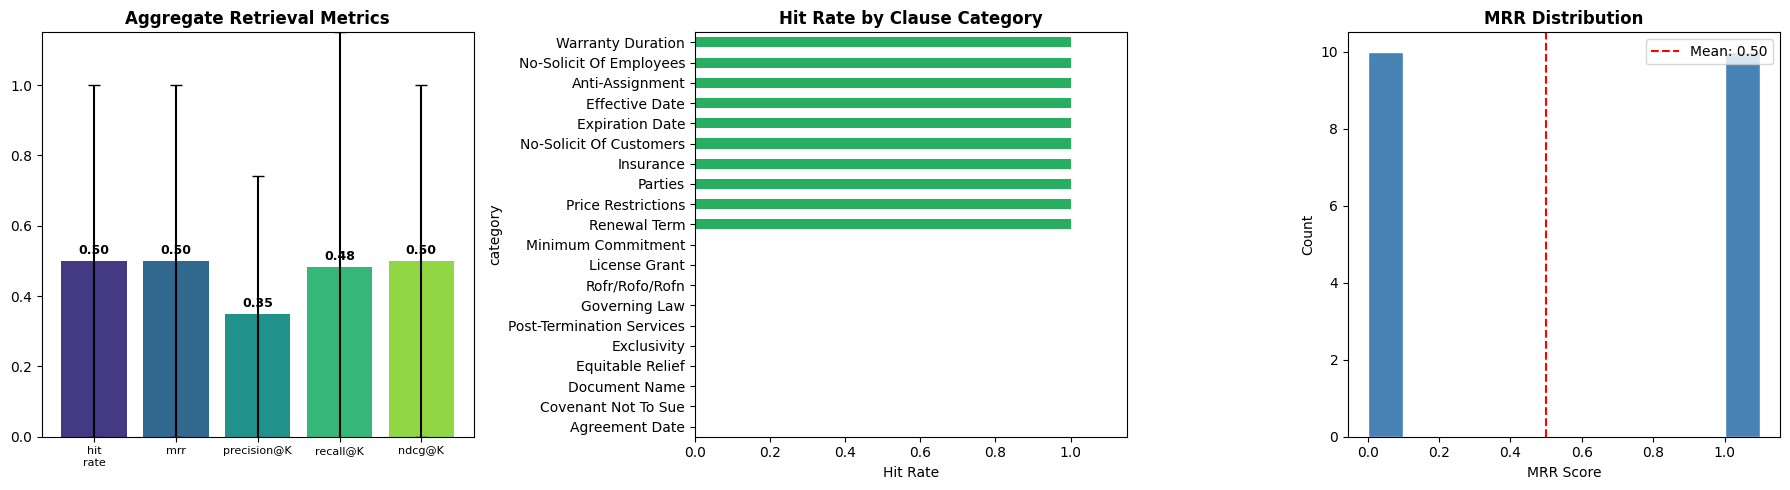

,category,hit_rate,mrr,precision_at_k,recall_at_k,ndcg_at_k
0,Document Name,0.0,0.0,0.0,0.000,0.0
1,Parties,1.0,1.0,0.5,0.031,1.0
2,Agreement Date,0.0,0.0,0.0,0.000,0.0
3,Effective Date,1.0,1.0,1.0,1.333,1.0
4,Expiration Date,1.0,1.0,0.5,2.000,1.0
5,Renewal Term,1.0,1.0,0.5,0.667,1.0
6,Governing Law,0.0,0.0,0.0,0.000,0.0
7,Exclusivity,0.0,0.0,0.0,0.000,0.0
8,No-Solicit Of Customers,1.0,1.0,1.0,1.000,1.0
9,No-Solicit Of Employees,1.0,1.0,0.5,0.333,1.0


In [20]:
# --- Failure Analysis ---
show_failures(results, eval_dataset)

# --- Visualization ---
plot_results(results)

# --- Per-query results table ---
results['dataframe'][['category', 'hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']].round(3)

Optional: RAGAS LLM-Based Metrics

In [60]:
# # === Optional: RAGAS LLM-based Metrics ===
# # Uncomment below for deeper semantic evaluation using RAGAS.
# # This uses your Groq API and is slower, but provides LLM-judged
# # context recall and precision scores.

# # Note: Groq free tier has rate limits. If you hit them, try reducing
# # the eval_dataset size or adding a delay.

# results_deep = evaluate_retrieval(
#     vector_store, eval_dataset, k=4,
#     chunks=all_splits, llm=llm, run_llm_metrics=True
# )
# plot_results(results_deep)

### Benchmark RAG on *entire* CUAD dataset.

##### Step 1: Build PDF Path Lookup & Create CUAD Vector Store

In [7]:
import glob
from pathlib import Path

# --- Build a lookup: contract_title -> pdf_path ---
PDF_BASE_DIR = "../datasets/CUAD_v1/full_contract_pdf"

all_pdf_paths = glob.glob(os.path.join(PDF_BASE_DIR, "**", "*.PDF"), recursive=True)
# Also catch lowercase .pdf just in case
all_pdf_paths += glob.glob(os.path.join(PDF_BASE_DIR, "**", "*.pdf"), recursive=True)
all_pdf_paths = list(set(all_pdf_paths))  # deduplicate

pdf_path_lookup: Dict[str, str] = {}
for p in all_pdf_paths:
    title = Path(p).stem  # filename without extension
    pdf_path_lookup[title] = p

print(f"Found {len(pdf_path_lookup)} PDF files")
print(f"CUAD dataset has {len(cuad_data['data'])} contracts")

# Quick check: how many contracts have a matching PDF?
matched = sum(1 for c in cuad_data['data'] if c['title'] in pdf_path_lookup)
print(f"Matched {matched}/{len(cuad_data['data'])} contracts to PDFs")

# --- Create a NEW Chroma vector store for the full dataset ---
cuad_v1_vector_store = Chroma(
    collection_name="cuad_v1_collection",
    embedding_function=embeddings,
    persist_directory="../collections/cuad_v1_collection",
)
print(f"\nCUAD v1 vector store initialized.")
print(f"Existing documents in collection: {cuad_v1_vector_store._collection.count()}")


Found 510 PDF files
CUAD dataset has 510 contracts
Matched 506/510 contracts to PDFs

CUAD v1 vector store initialized.
Existing documents in collection: 36730


##### Step 2: Chunk & Ingest All Contracts

In [8]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm.notebook import tqdm

# Only ingest if the collection is empty (avoids re-processing)
existing_count = cuad_v1_vector_store._collection.count()

if existing_count > 0:
    print(f"Collection already has {existing_count} documents. Skipping ingestion.")
    print("Delete the collection directory and restart if you want to re-ingest.")
else:
    cuad_text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000, chunk_overlap=200, add_start_index=True
    )

    processed = 0
    skipped = 0
    total_chunks = 0
    failed_titles = []

    pbar = tqdm(cuad_data['data'], desc="Ingesting contracts", unit="contract")
    for contract in pbar:
        title = contract['title']
        pdf_path = pdf_path_lookup.get(title)

        if not pdf_path:
            skipped += 1
            failed_titles.append((title, "No PDF found"))
            pbar.set_postfix(ok=processed, skip=skipped, chunks=total_chunks)
            continue

        try:
            loader = PyPDFLoader(pdf_path)
            docs = loader.load()

            if not docs:
                skipped += 1
                failed_titles.append((title, "PDF loaded but no pages"))
                pbar.set_postfix(ok=processed, skip=skipped, chunks=total_chunks)
                continue

            chunks = cuad_text_splitter.split_documents(docs)

            if chunks:
                cuad_v1_vector_store.add_documents(documents=chunks)
                total_chunks += len(chunks)

            processed += 1
            pbar.set_postfix(ok=processed, skip=skipped, chunks=total_chunks)

        except Exception as e:
            skipped += 1
            failed_titles.append((title, str(e)))
            pbar.set_postfix(ok=processed, skip=skipped, chunks=total_chunks)
            continue

    print(f"\n{'='*70}")
    print(f"  INGESTION COMPLETE")
    print(f"  Processed: {processed} contracts")
    print(f"  Skipped:   {skipped} contracts")
    print(f"  Total chunks ingested: {total_chunks}")
    print(f"{'='*70}")

    if failed_titles:
        print(f"\nFailed/skipped contracts ({len(failed_titles)}):")
        for t, reason in failed_titles[:20]:
            print(f"  - {t[:80]}... | {reason}")
        if len(failed_titles) > 20:
            print(f"  ... and {len(failed_titles) - 20} more")


Collection already has 36730 documents. Skipping ingestion.
Delete the collection directory and restart if you want to re-ingest.


##### Step 3: Helper — evaluate_single_contract()

In [9]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

def evaluate_single_contract(
    contract_title: str,
    cuad_path: str,
    vs,
    pdf_lookup: Dict[str, str],
    k: int = 4,
    verbose: bool = False,
) -> Optional[Dict]:
    """Evaluate RAG retrieval for a single CUAD contract.

    Loads the contract's PDF, chunks it, builds the ground-truth eval dataset
    from CUAD annotations, then runs evaluate_retrieval() against the given
    vector store — using hybrid search (Vector + BM25) filtered to only
    retrieve chunks from THIS contract.

    Args:
        contract_title: Exact title of the contract in CUAD_v1.json
        cuad_path: Path to CUAD_v1.json
        vs: The Chroma vector store to evaluate against
        pdf_lookup: Dict mapping contract titles to PDF file paths
        k: Number of chunks to retrieve per query
        verbose: If True, print detailed per-query results

    Returns:
        Dict with 'title', 'results', 'eval_dataset', 'chunks' keys,
        or None if the contract could not be processed.
    """
    pdf_path = pdf_lookup.get(contract_title)
    if not pdf_path:
        if verbose:
            print(f"  [SKIP] No PDF found for: {contract_title[:60]}...")
        return None

    try:
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        if not docs:
            if verbose:
                print(f"  [SKIP] PDF loaded but no pages: {contract_title[:60]}...")
            return None

        splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000, chunk_overlap=200, add_start_index=True
        )
        chunks = splitter.split_documents(docs)

        if not chunks:
            if verbose:
                print(f"  [SKIP] No chunks produced: {contract_title[:60]}...")
            return None

        eval_dataset = build_eval_dataset(cuad_path, contract_title, chunks)

        if not eval_dataset:
            if verbose:
                print(f"  [SKIP] No eval queries (all impossible): {contract_title[:60]}...")
            return None

        # --- HYBRID SEARCH: Vector + BM25 via EnsembleRetriever ---
        # PyPDFLoader stores the PDF path in each chunk's 'source' metadata.
        source_value = docs[0].metadata.get('source', pdf_path)

        # 1. BM25 Retriever — built in-memory from this contract's chunks
        bm25_retriever = BM25Retriever.from_documents(chunks)
        bm25_retriever.k = k

        # 2. Vector Retriever — Chroma, filtered by source metadata
        vector_retriever = vs.as_retriever(
            search_kwargs={"k": k, "filter": {"source": source_value}}
        )

        # 3. Ensemble — equal weights for semantic and keyword search
        ensemble_retriever = EnsembleRetriever(
            retrievers=[bm25_retriever, vector_retriever],
            weights=[0.5, 0.5],
        )

        def filtered_retrieve(query, num):
            return ensemble_retriever.invoke(query)

        results = evaluate_retrieval(
            filtered_retrieve, eval_dataset, k=k, chunks=chunks, verbose=verbose
        )

        return {
            'title': contract_title,
            'results': results,
            'eval_dataset': eval_dataset,
            'chunks': chunks,
        }

    except Exception as e:
        if verbose:
            print(f"  [ERROR] {contract_title[:60]}...: {e}")
        return None

print("Defined evaluate_single_contract() [with hybrid BM25 + vector retrieval].")

Defined evaluate_single_contract() [with hybrid BM25 + vector retrieval].


##### Step 4: Sanity Check — One Contract

Sanity check contract: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Evaluating 19 queries (k=4)...



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  [X]  1/19 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Document Name
  [+]  2/19 hit=1 mrr=1.00 P@4=0.75 R@4=0.09 | Parties
  [X]  3/19 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Agreement Date
  [+]  4/19 hit=1 mrr=1.00 P@4=0.50 R@4=1.00 | Effective Date
  [+]  5/19 hit=1 mrr=1.00 P@4=0.14 R@4=1.00 | Expiration Date
  [+]  6/19 hit=1 mrr=1.00 P@4=0.29 R@4=0.67 | Renewal Term
  [+]  7/19 hit=1 mrr=0.14 P@4=0.12 R@4=0.50 | Governing Law
  [X]  8/19 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Exclusivity
  [+]  9/19 hit=1 mrr=0.50 P@4=0.38 R@4=0.75 | No-Solicit Of Customers
  [+] 10/19 hit=1 mrr=1.00 P@4=0.25 R@4=0.33 | No-Solicit Of Employees
  [X] 11/19 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | Rofr/Rofo/Rofn
  [+] 12/19 hit=1 mrr=0.50 P@4=0.25 R@4=0.50 | Anti-Assignment
  [+] 13/19 hit=1 mrr=0.50 P@4=0.25 R@4=0.67 | Price Restrictions
  [+] 14/19 hit=1 mrr=1.00 P@4=0.25 R@4=0.33 | Minimum Commitment
  [X] 15/19 hit=0 mrr=0.00 P@4=0.00 R@4=0.00 | License Grant
  [+] 16/19 hit=1 mrr=1.00 P@4=0.14 R@4=0.25 | Post-Termi

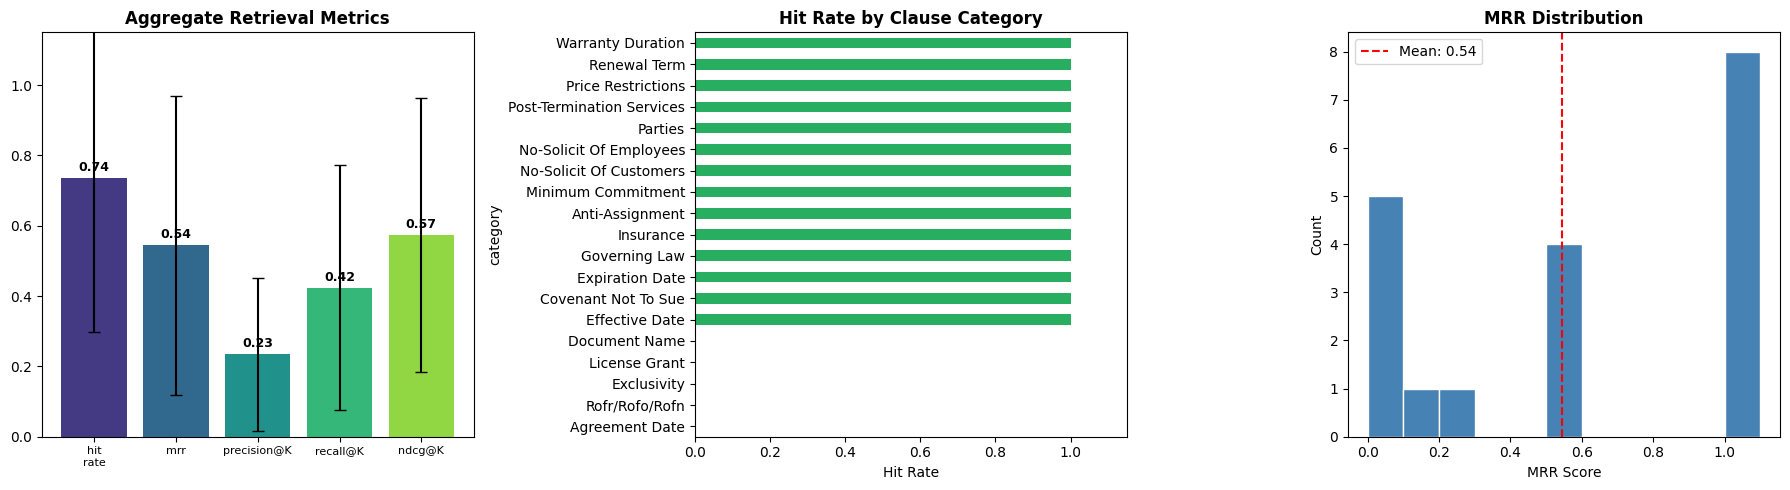

Failed to send compressed multipart ingest: langsmith.utils.LangSmithRateLimitError: Rate limit exceeded for https://api.smith.langchain.com/runs/multipart. HTTPError('429 Client Error: Too Many Requests for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Too many requests: tenant exceeded usage limits: Monthly unique traces usage limit exceeded"}\n')trace=019c61e8-7a55-7102-b1b3-07c4134bb767,id=019c61e8-7a56-7d32-a857-2045034719c7; trace=019c61e8-7a55-7102-b1b3-07c4134bb767,id=019c61e8-7a55-7102-b1b3-07c4134bb767; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24,id=019c61e8-7ad6-75a2-b99c-56c3d569de24; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24,id=019c61e8-7ad6-75a2-b99c-56dc26a667a4; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24,id=019c61e8-7ad6-75a2-b99c-56dc26a667a4; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24,id=019c61e8-7ad7-7ac3-8fdb-d340cab98785; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24,id=019c61e8-7ad7-7ac3-8fdb-d340cab98785; trace=019c61e8-7ad6-75a2-b99c-56c3d569de24

In [ ]:
# --- Sanity check: evaluate ONE contract with full output ---
SANITY_CHECK_TITLE = "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"

print(f"Sanity check contract: {SANITY_CHECK_TITLE}")
print("=" * 70)

sanity_result = evaluate_single_contract(
    SANITY_CHECK_TITLE,
    CUAD_PATH,
    cuad_v1_vector_store,
    pdf_path_lookup,
    k=4,
    verbose=True,
)

if sanity_result:
    sr = sanity_result['results']
    sd = sanity_result['eval_dataset']

    # Inspect a sample query
    print("\n" + "=" * 70)
    print("SAMPLE QUERY INSPECTION")
    print("=" * 70)
    inspect_query(sr, sd, query_idx=1)

    # Show failures
    print("\n" + "=" * 70)
    print("FAILURE ANALYSIS")
    print("=" * 70)
    show_failures(sr, sd)

    # Plot results
    print("\n" + "=" * 70)
    print("VISUALIZATION")
    print("=" * 70)
    plot_results(sr)

    # Per-query table
    sr['dataframe'][['category', 'hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']].round(3)
else:
    print("Sanity check failed — could not process the contract.")


##### Step 5: Full Dataset Aggregation

In [22]:
from tqdm.notebook import tqdm

def evaluate_full_dataset(
    cuad_path: str,
    cuad_data_obj: dict,
    vs,
    pdf_lookup: Dict[str, str],
    k: int = 4,
) -> Dict:
    """Evaluate RAG retrieval across the entire CUAD dataset.

    Iterates over all contracts, evaluates each one, and aggregates
    the metrics into a comprehensive report.

    Returns:
        Dict with 'aggregate_results', 'per_category', 'contract_summaries',
        'processed_count', 'skipped_count' keys.
    """
    all_per_query = []      # flat list of all per-query metric dicts
    contract_summaries = [] # one summary per contract
    processed = 0
    skipped = 0

    total = len(cuad_data_obj['data'])

    pbar = tqdm(cuad_data_obj['data'], desc="Evaluating contracts", unit="contract")
    for contract in pbar:
        title = contract['title']

        result = evaluate_single_contract(
            title, cuad_path, vs, pdf_lookup, k=k, verbose=False
        )

        if result is None:
            skipped += 1
        else:
            processed += 1
            all_per_query.extend(result['results']['per_query'])
            contract_summaries.append({
                'title': title,
                'n_queries': len(result['eval_dataset']),
                'summary': result['results']['summary'],
            })

        pbar.set_postfix(ok=processed, skip=skipped, queries=len(all_per_query))

    # --- Aggregate metrics across all queries ---
    metric_keys = ['hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']

    aggregate_summary = {}
    for key in metric_keys:
        vals = [r[key] for r in all_per_query if isinstance(r.get(key), (int, float))]
        if vals:
            aggregate_summary[key] = {
                'mean': float(np.mean(vals)),
                'std': float(np.std(vals)),
                'min': float(np.min(vals)),
                'max': float(np.max(vals)),
            }

    # --- Per-category aggregation ---
    categories = sorted(set(r['category'] for r in all_per_query))
    per_category = {}
    for cat in categories:
        cat_queries = [r for r in all_per_query if r['category'] == cat]
        cat_metrics = {}
        for key in metric_keys:
            vals = [r[key] for r in cat_queries if isinstance(r.get(key), (int, float))]
            if vals:
                cat_metrics[key] = {
                    'mean': float(np.mean(vals)),
                    'std': float(np.std(vals)),
                    'count': len(vals),
                }
        per_category[cat] = cat_metrics

    # --- Build aggregate dataframe for plotting ---
    agg_df = pd.DataFrame([
        {col: r.get(col) for col in ['query', 'category', *metric_keys, 'n_ref']}
        for r in all_per_query
    ])

    agg_results = {
        'summary': aggregate_summary,
        'per_query': all_per_query,
        'dataframe': agg_df,
    }

    # --- Print report ---
    print(f"\n{'='*70}")
    print(f"  FULL CUAD DATASET RETRIEVAL BENCHMARK")
    print(f"  k={k}  |  contracts={processed}  |  "
          f"total_queries={len(all_per_query)}  |  skipped={skipped}")
    print(f"{'='*70}")
    for key, s in aggregate_summary.items():
        bar_len = int(s['mean'] * 20)
        bar = '#' * bar_len + '.' * (20 - bar_len)
        print(f"  {key:30s} [{bar}] {s['mean']:.4f} (+/-{s['std']:.4f})")
    print(f"{'='*70}")

    # Per-category hit rates
    print(f"\n--- Hit Rate by Category ({len(categories)} categories) ---")
    cat_hr_data = []
    for cat in categories:
        hr = per_category[cat].get('hit_rate', {})
        if hr:
            cat_hr_data.append((cat, hr['mean'], hr['count']))
    cat_hr_data.sort(key=lambda x: x[1])
    for cat, mean_hr, count in cat_hr_data:
        bar_len = int(mean_hr * 20)
        bar = '#' * bar_len + '.' * (20 - bar_len)
        print(f"  {cat:40s} [{bar}] {mean_hr:.4f}  (n={count})")

    return {
        'aggregate_results': agg_results,
        'per_category': per_category,
        'contract_summaries': contract_summaries,
        'processed_count': processed,
        'skipped_count': skipped,
    }

print("Defined evaluate_full_dataset().")


Defined evaluate_full_dataset().


Evaluating contracts:   0%|          | 0/510 [00:00<?, ?contract/s]


  FULL CUAD DATASET RETRIEVAL BENCHMARK
  k=4  |  contracts=506  |  total_queries=6572  |  skipped=4
  hit_rate                       [##############......] 0.7047 (+/-0.4562)
  mrr                            [########............] 0.4243 (+/-0.3954)
  precision_at_k                 [###.................] 0.1975 (+/-0.2115)
  recall_at_k                    [########............] 0.4113 (+/-0.4019)
  ndcg_at_k                      [#########...........] 0.4856 (+/-0.3711)

--- Hit Rate by Category (41 categories) ---
  Agreement Date                           [#####...............] 0.2541  (n=425)
  Volume Restriction                       [#######.............] 0.3659  (n=82)
  Effective Date                           [########............] 0.4106  (n=358)
  Most Favored Nation                      [########............] 0.4286  (n=28)
  Unlimited/All-You-Can-Eat-License        [#########...........] 0.4706  (n=17)
  Competitive Restriction Exception        [#########...........] 0.47

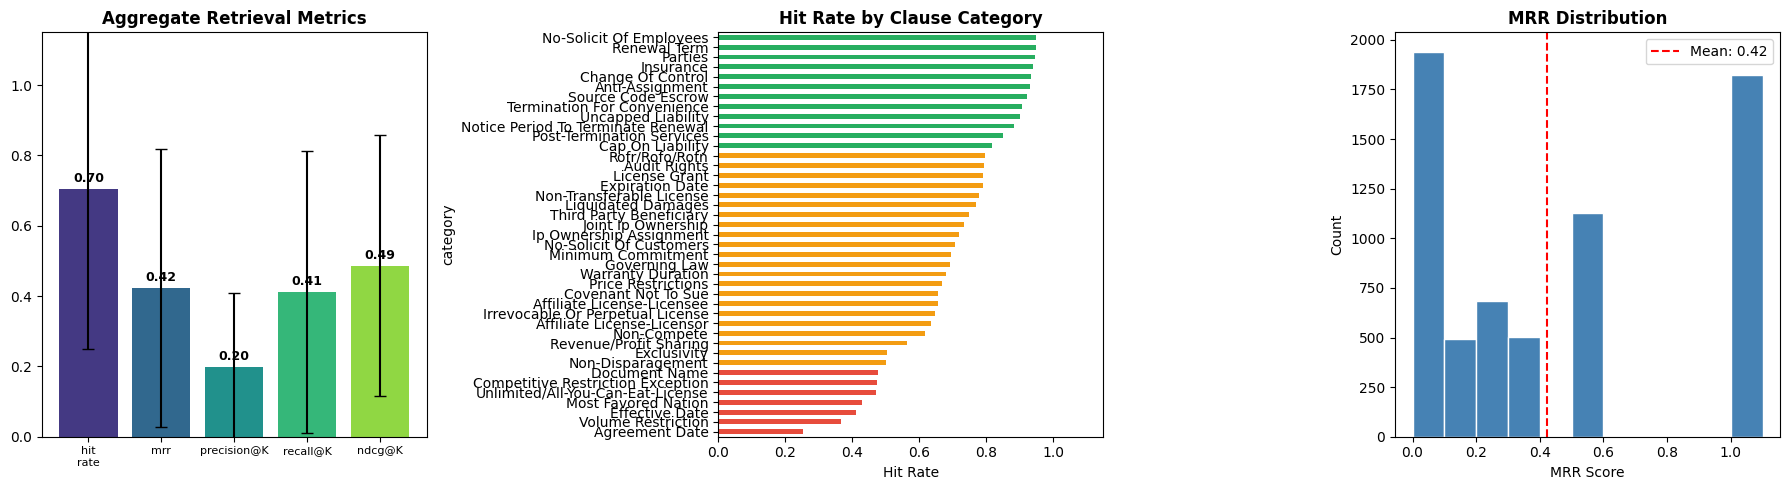

In [23]:
# --- Run full dataset evaluation ---
full_results = evaluate_full_dataset(
    CUAD_PATH,
    cuad_data,
    cuad_v1_vector_store,
    pdf_path_lookup,
    k=4,
)

# --- Plot aggregate results ---
print("\n" + "=" * 70)
print("AGGREGATE VISUALIZATION")
print("=" * 70)
plot_results(full_results['aggregate_results'])


#### Improving RAG Performance: Part 2.